In [43]:
import matplotlib.pyplot as plt
from torch import nn
import seaborn as sns
import torch
import torch.nn.functional as F
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [20]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [21]:
# build dataset
block_size = 3  #context length, how many characters do we take to predict the next character

def build_dataset(items):
  x_temp = []
  y_temp = []
  for w in items:
    context = [0] * block_size  #[0, 0, 0]
    for ch in w + '.':
      ix = stoi[ch]
      x_temp.append(context)
      y_temp.append(ix)
      # print(''.join(itos[i] for i in context), "--->", itos[ix])
      context = context[1:] + [ix]  # crop and append
  return torch.tensor(x_temp, device=device), torch.tensor(y_temp, device=device)

import random
random.seed(42)
random.shuffle(words)
n = len(words)
x_train, y_train = build_dataset(words[:int(0.8*n)])
x_dev, y_dev = build_dataset(words[int(0.8*n):int(0.9*n)])
x_test, y_test = build_dataset(words[int(0.9*n):])

x_train.shape, y_train.shape, x_dev.shape, y_dev.shape, x_test.shape, y_test.shape


(torch.Size([182625, 3]),
 torch.Size([182625]),
 torch.Size([22655, 3]),
 torch.Size([22655]),
 torch.Size([22866, 3]),
 torch.Size([22866]))

In [22]:
g = torch.Generator(device=device).manual_seed(2147483647)
#F.one_hot(torch.tensor(5), num_classes=27).float() @ C
EMB_SIZE = 10  # embedding dimension
HIDDEN_SIZE = 200
VOCAB_SIZE = len(itos)


C = torch.randn((VOCAB_SIZE, EMB_SIZE), generator=g, requires_grad=True, device=device)
W1 = torch.randn((EMB_SIZE * block_size, HIDDEN_SIZE), generator=g, requires_grad=True, device=device)
W1.data *= (5/3) / (EMB_SIZE * block_size)**0.5 # Kaiming init
# b1 will be canceled when we do batch-normalization, so we don't need to initialize it
# bn_bias replaces b1, so we can just omit b1
# b1.data *= 0.01
W2 = torch.randn((HIDDEN_SIZE, VOCAB_SIZE), generator=g, requires_grad=True, device=device)
W2.data *= 0.01
b2 = torch.zeros(VOCAB_SIZE, requires_grad=True, device=device)

# BatchNorm parameters
bn_gain = torch.ones((1, HIDDEN_SIZE), requires_grad=True, device=device)
bn_bias = torch.zeros((1, HIDDEN_SIZE), requires_grad=True, device=device)
bn_mean_running = torch.zeros((1, HIDDEN_SIZE), device=device)
bn_std_running = torch.ones((1, HIDDEN_SIZE), device=device)

parameters = [C, W1, W2, b2, bn_gain, bn_bias]
print('number of parameters:', sum(p.nelement() for p in parameters))


number of parameters: 12097


In [23]:
lossi = []
stepi = []

In [24]:
# same optimization as last time
MAX_STEPS = 200000
BATCH_SIZE = 32

# training loop
for i in range(MAX_STEPS):
  # minibatch of 32
  ix = torch.randint(0, x_train.shape[0], (BATCH_SIZE,), generator=g, device=device)
  Xb, Yb = x_train[ix], y_train[ix]
  emb = C[Xb] # embed the characters into vectors
  # both are equivalent as long as emb has shape (batch_size, block_size, emb_size).
  # Example:
  # emb.shape == (32, 3, 10)
  # emb.view(32, -1) -> (32, 30)
  # emb.view(-1, 10 * 3) -> (32, 30)
  # So both flatten each sample’s 3 character embeddings into one 30-dim vector while keeping the batch dimension. In the notebook, the second line overwrites the first, and that is the active one:
  # z = emb.view(emb.shape[0], -1) # concatenate the vectors
  z = emb.view(-1, EMB_SIZE * block_size)

  # Linear layer
  h_preact = z @ W1 # + b1 # hidden layer pre-activation

  # BatchNorm layer
  # -------------------------------------------------------------
  bn_meani = h_preact.mean(0, keepdim=True)
  bn_stdi = h_preact.std(0, keepdim=True)
  h_preact = bn_gain * (h_preact - bn_meani) / bn_stdi + bn_bias
  with torch.no_grad():
    bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_meani
    bn_std_running = 0.999 * bn_std_running + 0.001 * bn_stdi
  # -------------------------------------------------------------

   # Non-linearity
  h = torch.tanh(h_preact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # print(i, loss.item())
  # set grad to 0, zero_grad()
  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 0.5 * MAX_STEPS else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{MAX_STEPS:7d}: {loss.item():.4f}')
  stepi.append(i)
  lossi.append(loss.log10().item())

# softmax activation
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# built-in softmax

print('Final Loss = ', loss.item())

# computes all gradients
for p in parameters:
  p.data -= 0.01 * p.grad

bn_mean_running, bn_std_running

      0/ 200000: 3.3195
  10000/ 200000: 2.4145
  20000/ 200000: 2.3325
  30000/ 200000: 1.9968
  40000/ 200000: 2.1420
  50000/ 200000: 1.8543
  60000/ 200000: 2.0658
  70000/ 200000: 2.3749
  80000/ 200000: 1.7567
  90000/ 200000: 2.1471
 100000/ 200000: 1.9758
 110000/ 200000: 2.2732
 120000/ 200000: 2.2282
 130000/ 200000: 2.2719
 140000/ 200000: 2.0277
 150000/ 200000: 2.1609
 160000/ 200000: 2.1316
 170000/ 200000: 2.2845
 180000/ 200000: 1.8789
 190000/ 200000: 2.1965
Final Loss =  2.1533992290496826


(tensor([[-2.2805,  0.7479, -0.9736,  1.2432,  1.0595,  1.1461,  1.9935, -2.1606,
           0.5049,  1.3918, -2.1098, -2.6220, -0.6690, -0.8251,  0.6308, -1.0398,
           0.6428, -2.5176,  0.1718,  1.7960, -0.8732,  0.0660,  0.5913,  0.2933,
           1.5277,  0.4458,  1.2328,  0.7751,  0.6470,  1.8598, -0.4358, -0.8935,
           0.3956, -0.1871, -0.5009, -1.1910, -2.4601,  0.5491, -0.1644,  0.5399,
          -0.0249, -0.8039, -0.8912, -0.3977,  0.6845,  0.5779,  1.7142, -0.1089,
           1.8770,  1.6436,  1.5694,  0.0048,  1.9112,  0.7781,  0.7019, -1.7726,
          -0.1979,  0.6721,  1.3903, -1.4569, -1.3679,  1.1886,  0.4953,  0.2790,
           1.2363,  1.7446, -1.2130,  2.0523, -0.4463,  0.2198, -0.4737,  0.0385,
           0.2793, -1.6711, -3.1084,  0.5610,  0.7285, -0.0095,  0.6345,  0.8193,
           0.3579,  1.6020,  1.6460,  0.5181,  0.2430,  0.2048, -1.8639,  0.5575,
           0.7842, -0.2686, -0.4444,  1.3392, -1.0873, -0.8804, -0.7736,  0.2616,
          -0.167

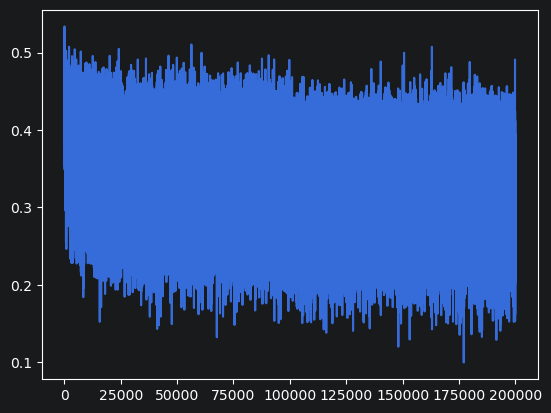

In [25]:
plt.plot(lossi)

tensor(-0.0015) tensor(0.9913)
tensor(0.0002) tensor(1.0129)


(array([4.10713821e-05, 6.16070731e-05, 1.23214146e-04, 2.46428292e-04,
        2.87499674e-04, 5.33927967e-04, 9.65177478e-04, 1.47856975e-03,
        2.56696138e-03, 4.80535170e-03, 7.74195552e-03, 1.25473072e-02,
        2.12339045e-02, 3.49517461e-02, 5.05999427e-02, 7.61668780e-02,
        1.13685586e-01, 1.65866776e-01, 2.23222961e-01, 2.85322891e-01,
        3.51160317e-01, 3.98145978e-01, 4.29483442e-01, 4.15786136e-01,
        3.73934398e-01, 3.13354109e-01, 2.48317576e-01, 1.85416754e-01,
        1.32906992e-01, 9.08909685e-02, 6.07035027e-02, 3.99419191e-02,
        2.49508646e-02, 1.65106956e-02, 9.69284617e-03, 5.27767259e-03,
        3.16249642e-03, 2.09464048e-03, 1.25267715e-03, 6.98213495e-04,
        4.72320894e-04, 3.28571056e-04, 4.10713821e-05, 6.16070731e-05,
        0.00000000e+00, 4.10713821e-05, 2.05356910e-05, 0.00000000e+00,
        2.05356910e-05, 2.05356910e-05]),
 array([-5.52732611, -5.28384757, -5.04036903, -4.7968905 , -4.55341196,
        -4.30993342, 

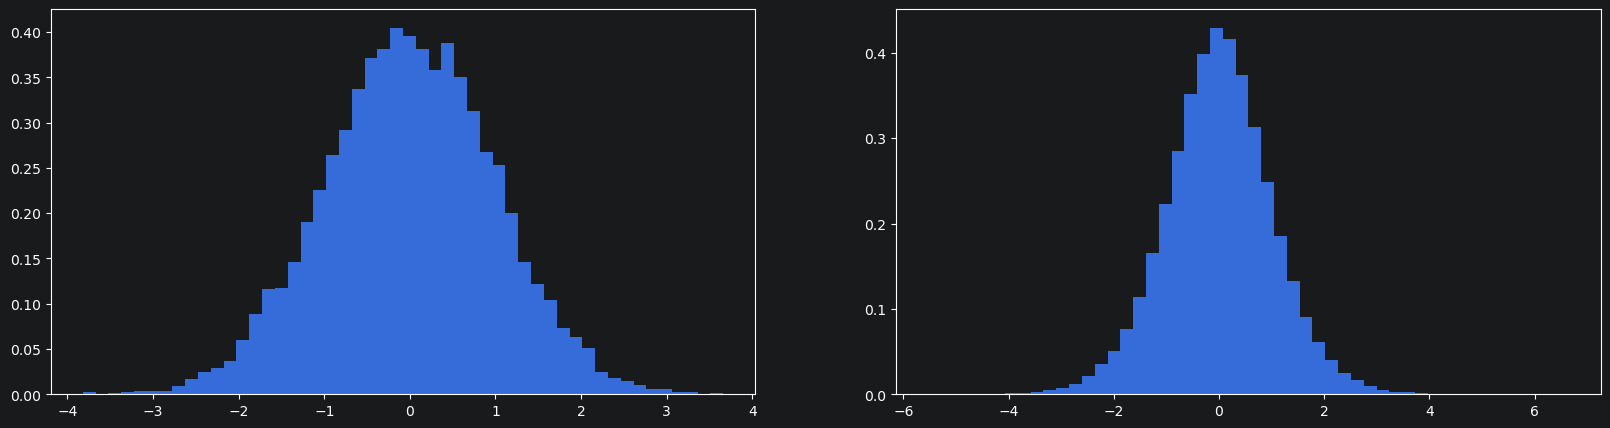

In [26]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), bins=50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), bins=50, density=True)

In [27]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[x_train] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h_preact = embcat @ W1 # + b1
    bn_mean_train = h_preact.mean(0, keepdim=True)
    bn_std_train = h_preact.std(0, keepdim=True)

bn_mean_train, bn_std_train

(tensor([[-2.2630,  0.7440, -0.9873,  1.2440,  1.0508,  1.1506,  1.9957, -2.1494,
           0.5155,  1.4081, -2.0931, -2.6192, -0.6647, -0.8163,  0.6288, -1.0558,
           0.6436, -2.5102,  0.1936,  1.8107, -0.8814,  0.0482,  0.5888,  0.2882,
           1.5253,  0.4484,  1.2338,  0.7814,  0.6497,  1.8599, -0.4258, -0.8920,
           0.3901, -0.1874, -0.5042, -1.1960, -2.4628,  0.5567, -0.1743,  0.5371,
          -0.0151, -0.7866, -0.8950, -0.3994,  0.6823,  0.5640,  1.7088, -0.1027,
           1.8928,  1.6530,  1.5693,  0.0160,  1.9216,  0.7832,  0.7132, -1.7664,
          -0.1973,  0.6744,  1.3759, -1.4519, -1.3605,  1.1991,  0.5027,  0.2812,
           1.2394,  1.7623, -1.2024,  2.0564, -0.4494,  0.2034, -0.4631,  0.0254,
           0.2916, -1.6988, -3.1131,  0.5777,  0.7234, -0.0140,  0.6274,  0.8337,
           0.3553,  1.6142,  1.6694,  0.5123,  0.2328,  0.2085, -1.8631,  0.5580,
           0.7945, -0.2756, -0.4363,  1.3314, -1.0895, -0.8746, -0.7719,  0.2605,
          -0.157

In [28]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (x_train, y_train),
    'val': (x_dev, y_dev),
    'test': (x_test, y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h_preact = embcat @ W1 # + b1
  #h_preact = bn_gain * (h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True) + bn_bias
  h_preact = bn_gain * (h_preact - bn_mean_running) / bn_std_running + bn_bias
  h = torch.tanh(h_preact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.0671048164367676
val 2.1066226959228516
test 2.1076207160949707


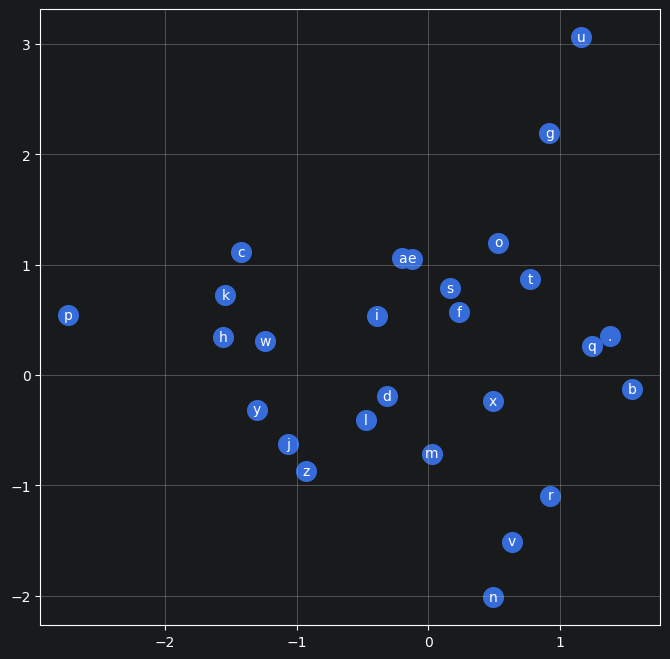

In [29]:
# visualize the chars
C_plot = C.detach().cpu()

plt.figure(figsize=(8, 8))
plt.scatter(C_plot[:, 0].numpy(), C_plot[:, 1].numpy(), s=200)
for i in range(C_plot.shape[0]):
    plt.text(C_plot[i, 0].item(), C_plot[i, 1].item(), itos[i],
             ha="center", va="center", color="white")
plt.grid(True, which="both")


In [30]:
# ---- inference: next-char prediction for a 4-char context ----
@torch.no_grad()
def predict_next_char(context4):
    # context4 must have length 4
    x = torch.tensor([[stoi[c] for c in context4]], dtype=torch.long)  # (1,4)
    emb = C[x]                       # (1,4,10)
    embcat = emb.view(1, EMB_SIZE * block_size)

    h_preact = embcat @ W1 # + b1
    h_preact = bn_gain * (h_preact - bn_mean_running) / bn_std_running + bn_bias
    h = torch.tanh(h_preact) # (N, n_hidden)

    logits = h @ W2 + b2             # (1,27)
    probs = F.softmax(logits, dim=1) # (1,27)
    ix = torch.argmax(probs, dim=1).item()
    return itos[ix], probs[0]

ch, probs = predict_next_char("onl")
print("predicted next char:", ch)

predicted next char: e


In [31]:

# ---- optional: generate a word ----
@torch.no_grad()
def generate_one():
    context = [0] * block_size
    out = []
    while True:
        x = torch.tensor([context], dtype=torch.long)   # (1,4)
        emb = C[x]
        embcat = emb.view(1, -1)

        h_preact = embcat @ W1 # + b1
        h_preact = bn_gain * (h_preact - bn_mean_running) / bn_std_running + bn_bias
        h = torch.tanh(h_preact) # (N, n_hidden)

        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:   # '.' token
            break
        out.append(itos[ix])
    return "".join(out)

for _ in range(20):
  print(generate_one())

andaylyn
brenny
raytises
orus
tysha
rubhaviknazhayl
alvier
ayson
prissee
kena
pex
elone
lakynz
falie
yura
milajmeen
bryanitalys
jonni
drefson
adric


In [56]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g, device=device) # / fan_in**0.5
    self.bias = torch.zeros(fan_out, device=device) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

  # bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_meani
  #
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim, device=device) # bn_gain
    self.beta = torch.zeros(dim, device=device) # bn_bias
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim, device=device)
    self.running_var = torch.ones(dim, device=device)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator(device=device).manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g, device=device)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

# layers = [
#   nn.Linear(n_embd * block_size, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
#   nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
#   nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
#   nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
#   nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
#   nn.Linear(           n_hidden, vocab_size, bias=False), nn.BatchNorm1d(vocab_size),
# ]



# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].beta *= 0.1
  # layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1 # 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [53]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,), generator=g, device=device)
  Xb, Yb = x_train[ix], y_train[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
    x.retain_grad()
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  # for layer in layers:
  #   layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 2.0021


Text(0.5, 1.0, 'activation distribution')

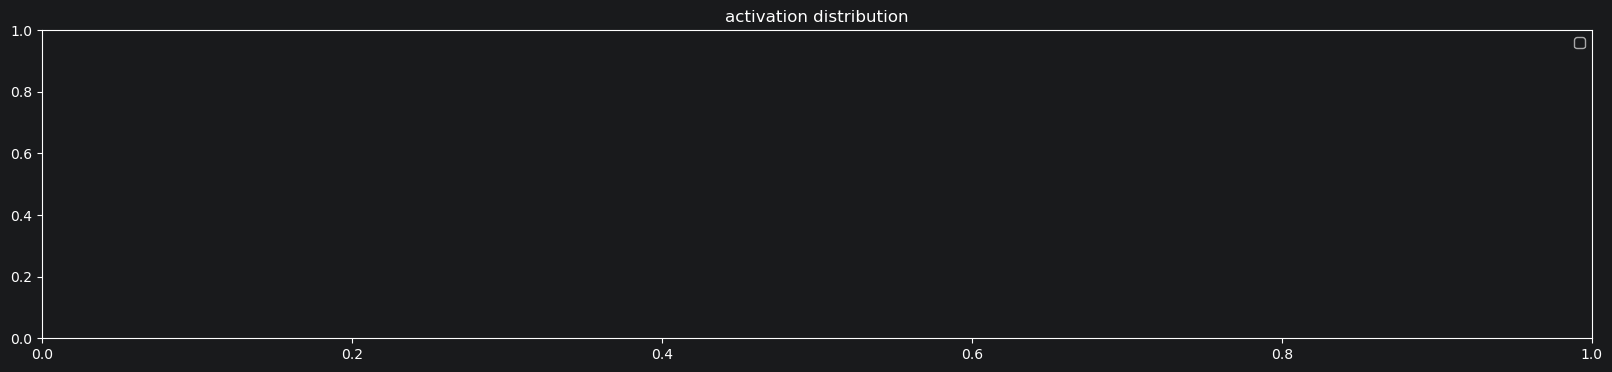

In [54]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    t_cpu = t.detach().cpu()
    hy, hx = torch.histogram(t_cpu, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.093911e-03
layer 5 (      Tanh): mean -0.000000, std 2.661322e-03
layer 8 (      Tanh): mean +0.000000, std 2.426212e-03
layer 11 (      Tanh): mean +0.000000, std 2.269458e-03
layer 14 (      Tanh): mean +0.000000, std 1.983030e-03


Text(0.5, 1.0, 'gradient distribution')

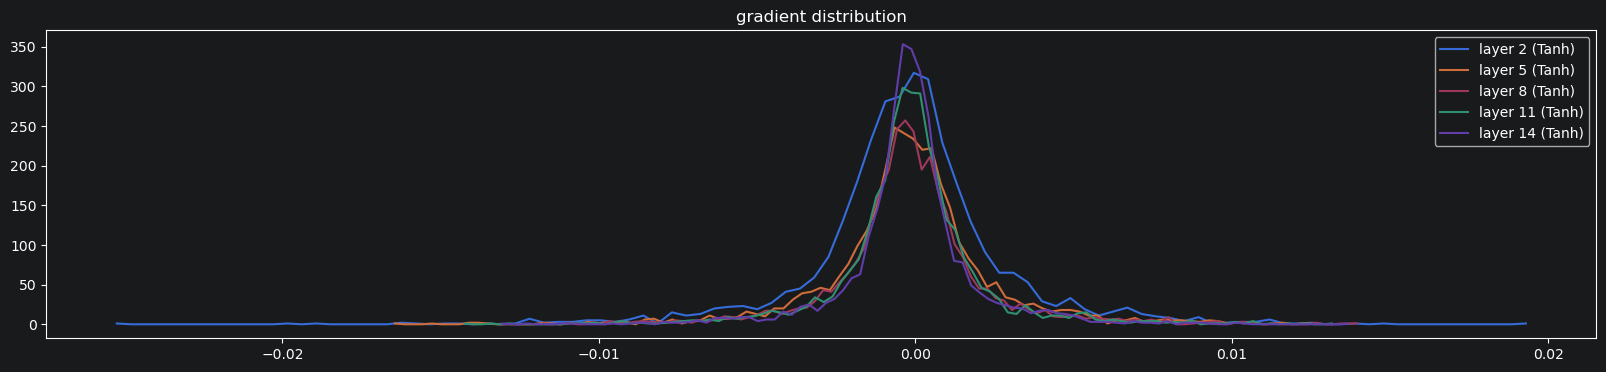

In [35]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    t_cpu = t.detach().cpu()
    hy, hx = torch.histogram(t_cpu, density=False)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 6.705947e-03 | grad:data ratio 6.700179e-03
weight  (30, 100) | mean -0.000003 | std 2.026517e-03 | grad:data ratio 1.977297e-03
weight (100, 100) | mean +0.000013 | std 1.104427e-03 | grad:data ratio 1.108055e-03
weight (100, 100) | mean +0.000005 | std 9.566541e-04 | grad:data ratio 9.497146e-04
weight (100, 100) | mean +0.000003 | std 8.406343e-04 | grad:data ratio 8.380435e-04
weight (100, 100) | mean +0.000001 | std 7.872586e-04 | grad:data ratio 7.840729e-04
weight  (100, 27) | mean -0.000002 | std 1.212761e-03 | grad:data ratio 1.226612e-03


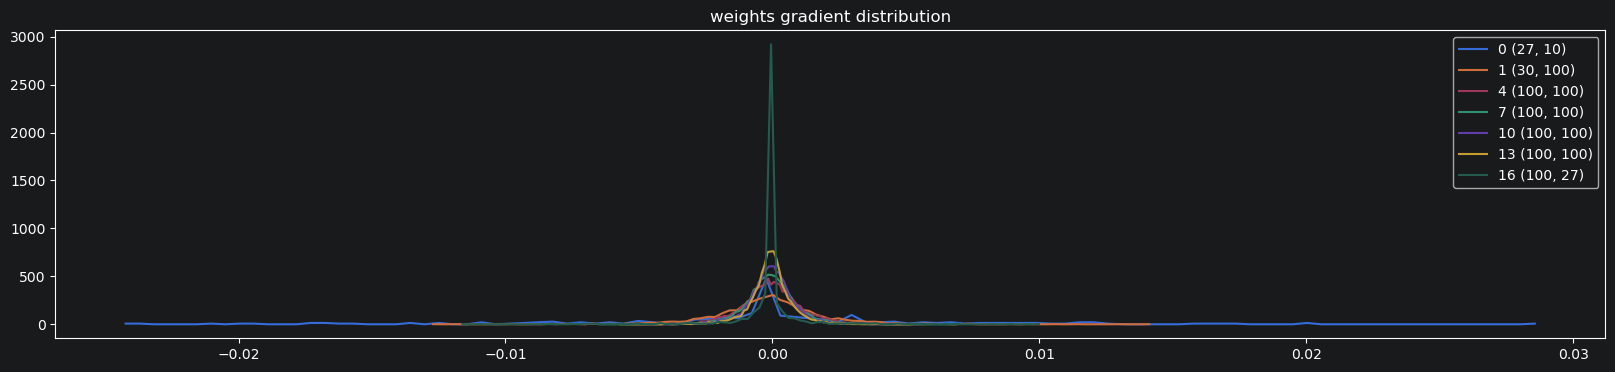

In [36]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    t_cpu = t.detach().cpu()
    hy, hx = torch.histogram(t_cpu, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

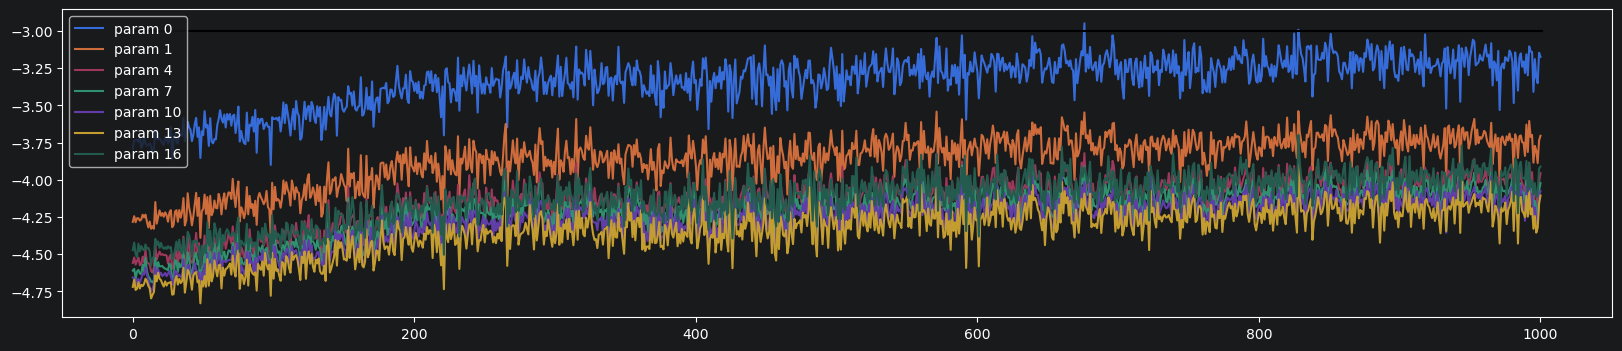

In [37]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [38]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (x_train, y_train),
    'val': (x_dev, y_dev),
    'test': (x_test, y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.6979496479034424
val 2.6949265003204346


In [39]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context], device=device)] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carpahxqae.
hlvihkimrsx.
eaty.
hnaa.
sne.
rrhnen.
ape.
rhc.
iaqei.
nermnia.
ceaiiv.
eslein.
hhlm.
eoin.
qeinn.
srlin.
a.
janbq.
wqjelogijaryxixfkaeenirsai.
ed.


interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

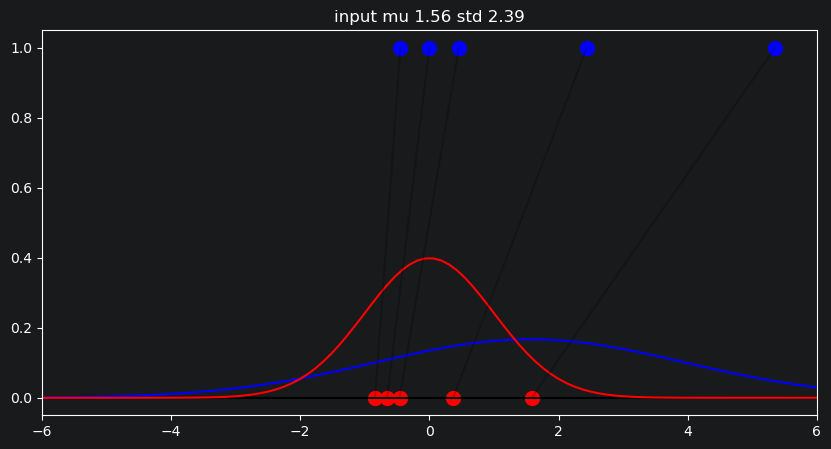

In [40]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):

  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));

In [41]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [42]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator(device=device).manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g, device=device)
w = torch.randn((n, n), requires_grad=True, generator=g, device=device) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g, device=device)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953053593635559
